# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [3]:
test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
data.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [7]:
data.drop('Id', axis=1, inplace=True)
test_data.drop('Id', axis=1, inplace=True)

## Data Preprocessing

In [8]:
feature = np.array(data.columns.to_list())

In [9]:
nan_val_col = feature[np.array(data.isnull().sum())>145]
nan_val_col

array(['LotFrontage', 'Alley', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'], dtype='<U13')

In [10]:
data_temp = data.drop(nan_val_col, axis=1)

In [11]:
test_data.drop(nan_val_col, axis=1, inplace=True)

In [12]:
cat_features = np.array([i for i in data_temp.columns.tolist() if data_temp[i].dtype == 'object'])
cont_features = np.array([i for i in data_temp.columns.tolist() if data_temp[i].dtype != 'object'])

### Analyze Categorial Features

In [13]:
feat = data_temp.columns.to_list()
len(feat)

74

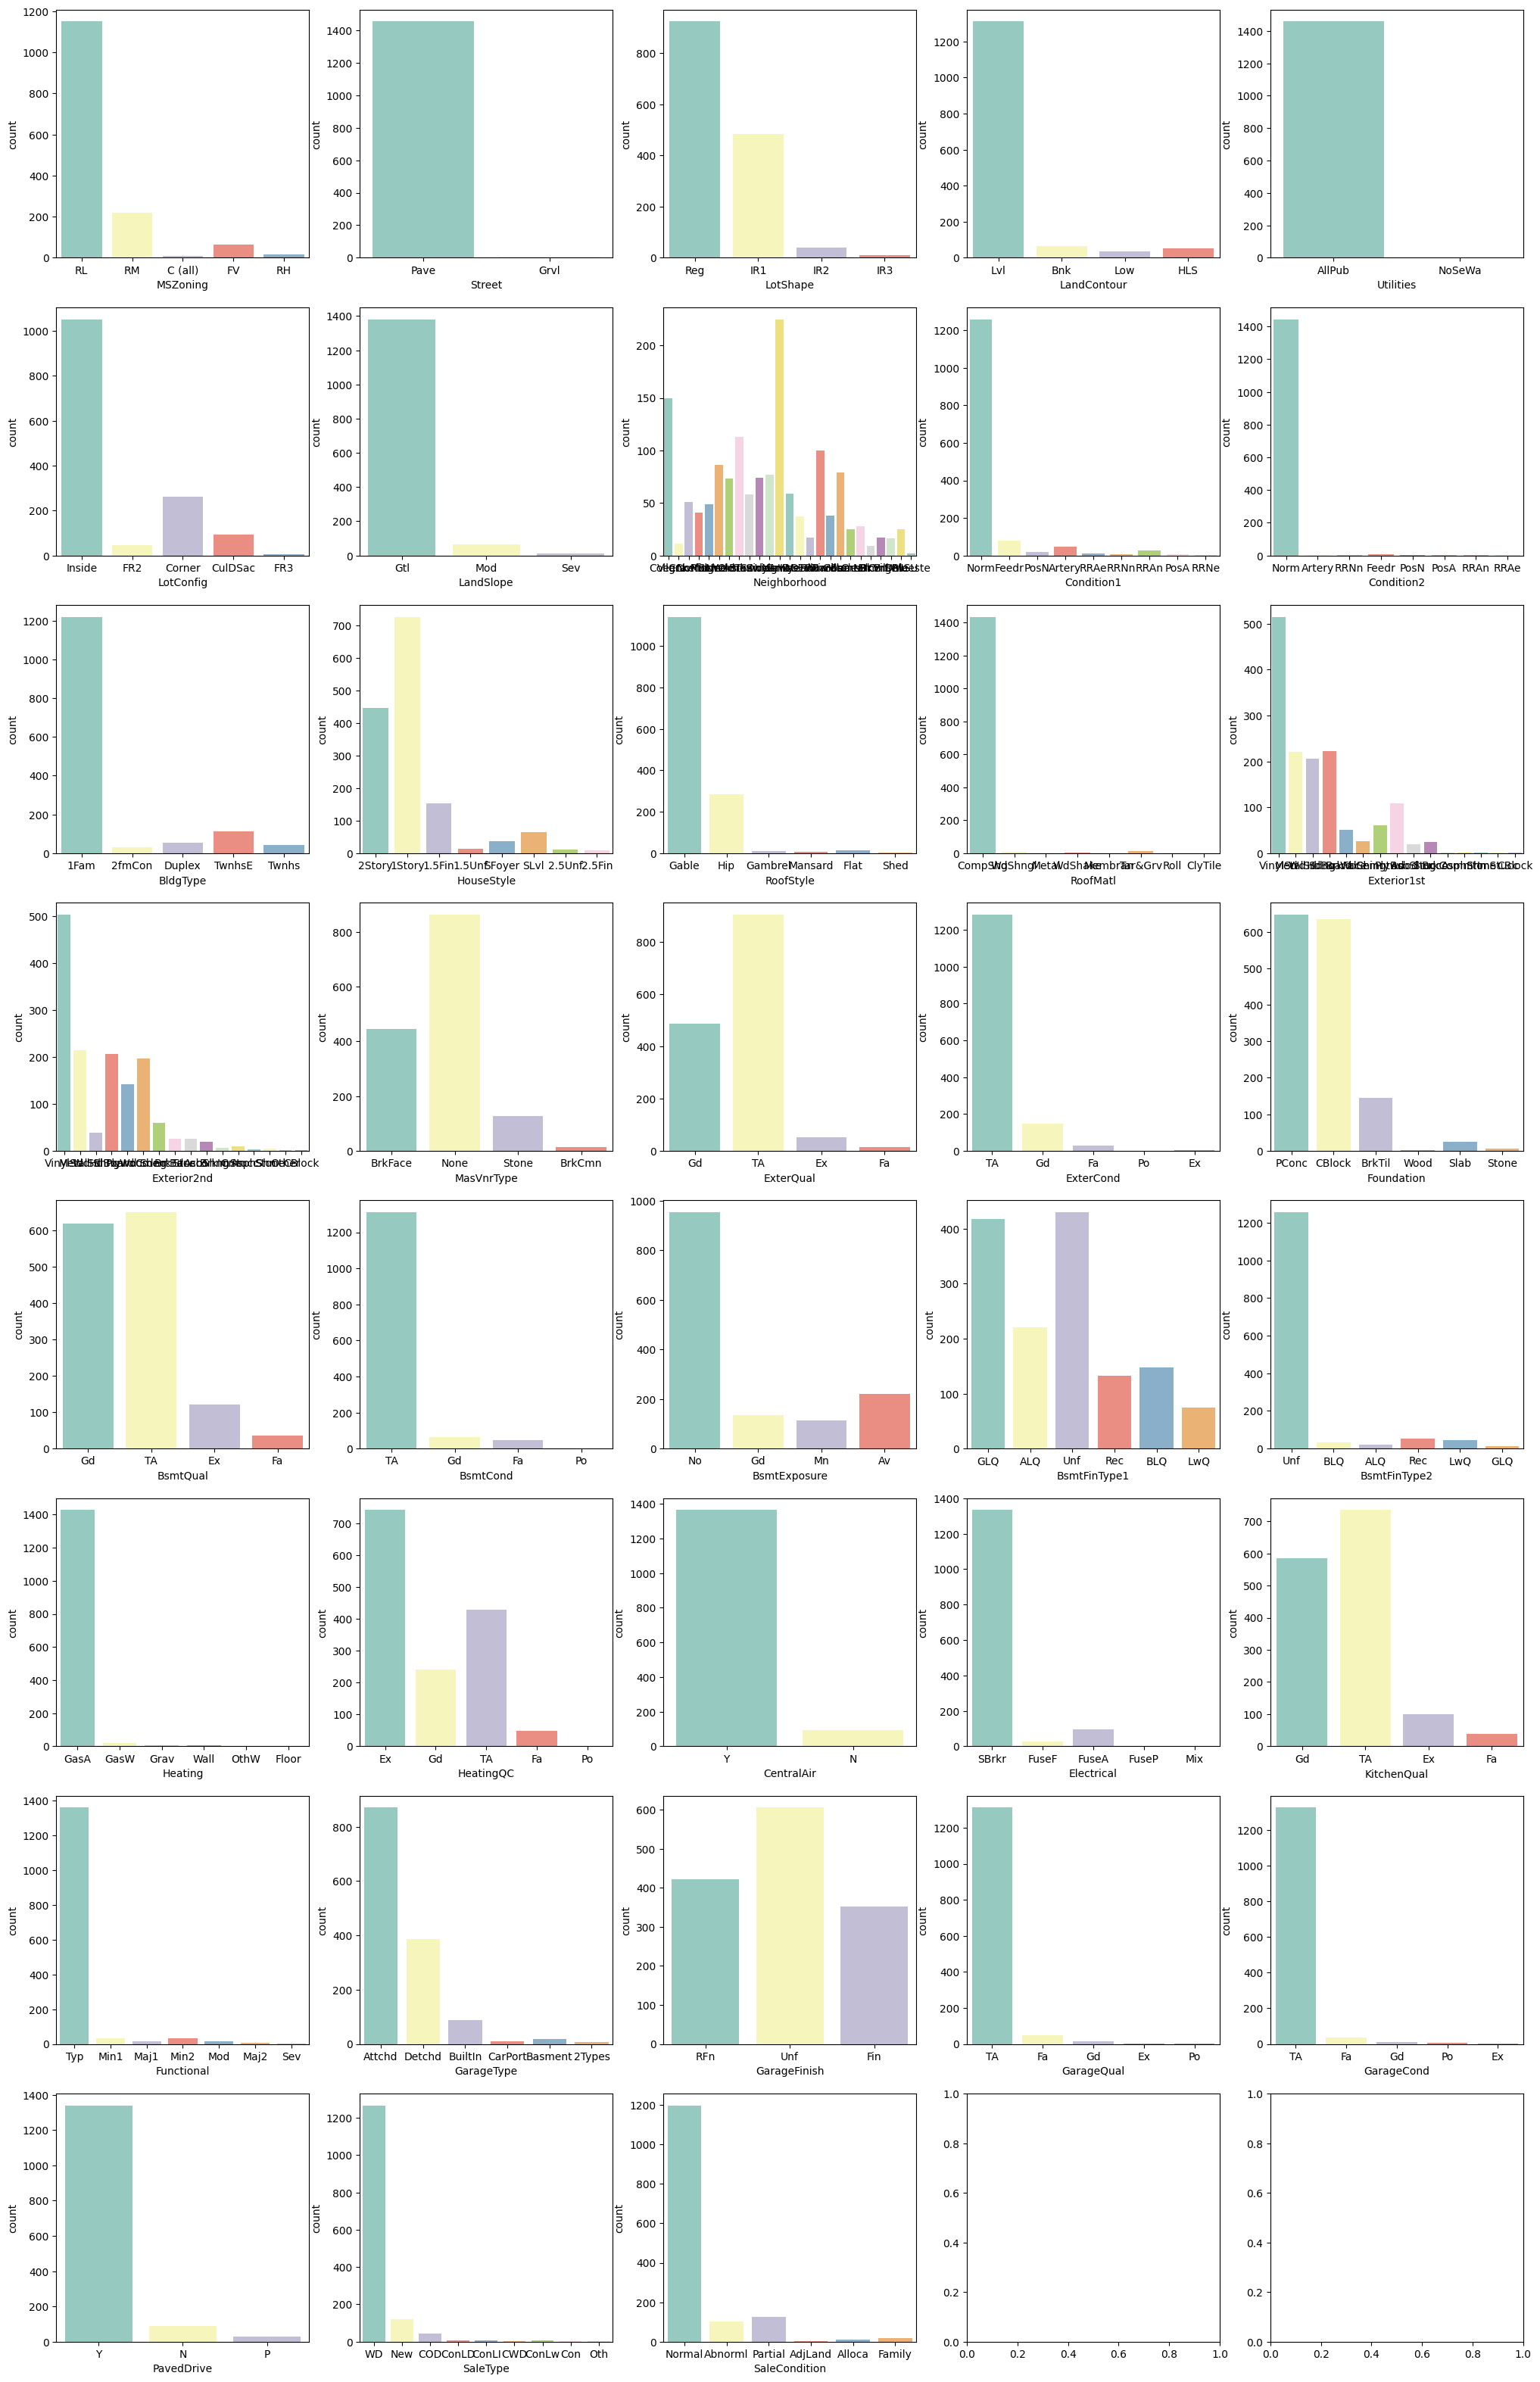

In [14]:
f,ax = plt.subplots(8,5, figsize=(25,40))
k=0
for i in range(8):
    for j in range(5):
        while k<38:
            sns.countplot(x=cat_features[k], data=data_temp, ax=ax[i][j], palette='Set3')
            break
        k=k+1

In [15]:
# Lets remove the features that only focused on one category.
data_temp.drop(['SaleCondition', 'SaleType', 'PavedDrive', 'GarageCond', 'GarageQual', 'Functional', 'Electrical',
                'CentralAir', 'Heating', 'BsmtFinType2', 'BsmtCond', 'ExterCond', 'RoofMatl', 'BldgType', 'Condition2',
                'Condition1', 'LandSlope', 'Utilities', 'LandContour', 'Street', 'MSZoning'], axis=1, inplace=True)

In [16]:
# test data
test_data.drop(['SaleCondition', 'SaleType', 'PavedDrive', 'GarageCond', 'GarageQual', 'Functional', 'Electrical',
                'CentralAir', 'Heating', 'BsmtFinType2', 'BsmtCond', 'ExterCond', 'RoofMatl', 'BldgType', 'Condition2',
                'Condition1', 'LandSlope', 'Utilities', 'LandContour', 'Street', 'MSZoning'], axis=1, inplace=True)

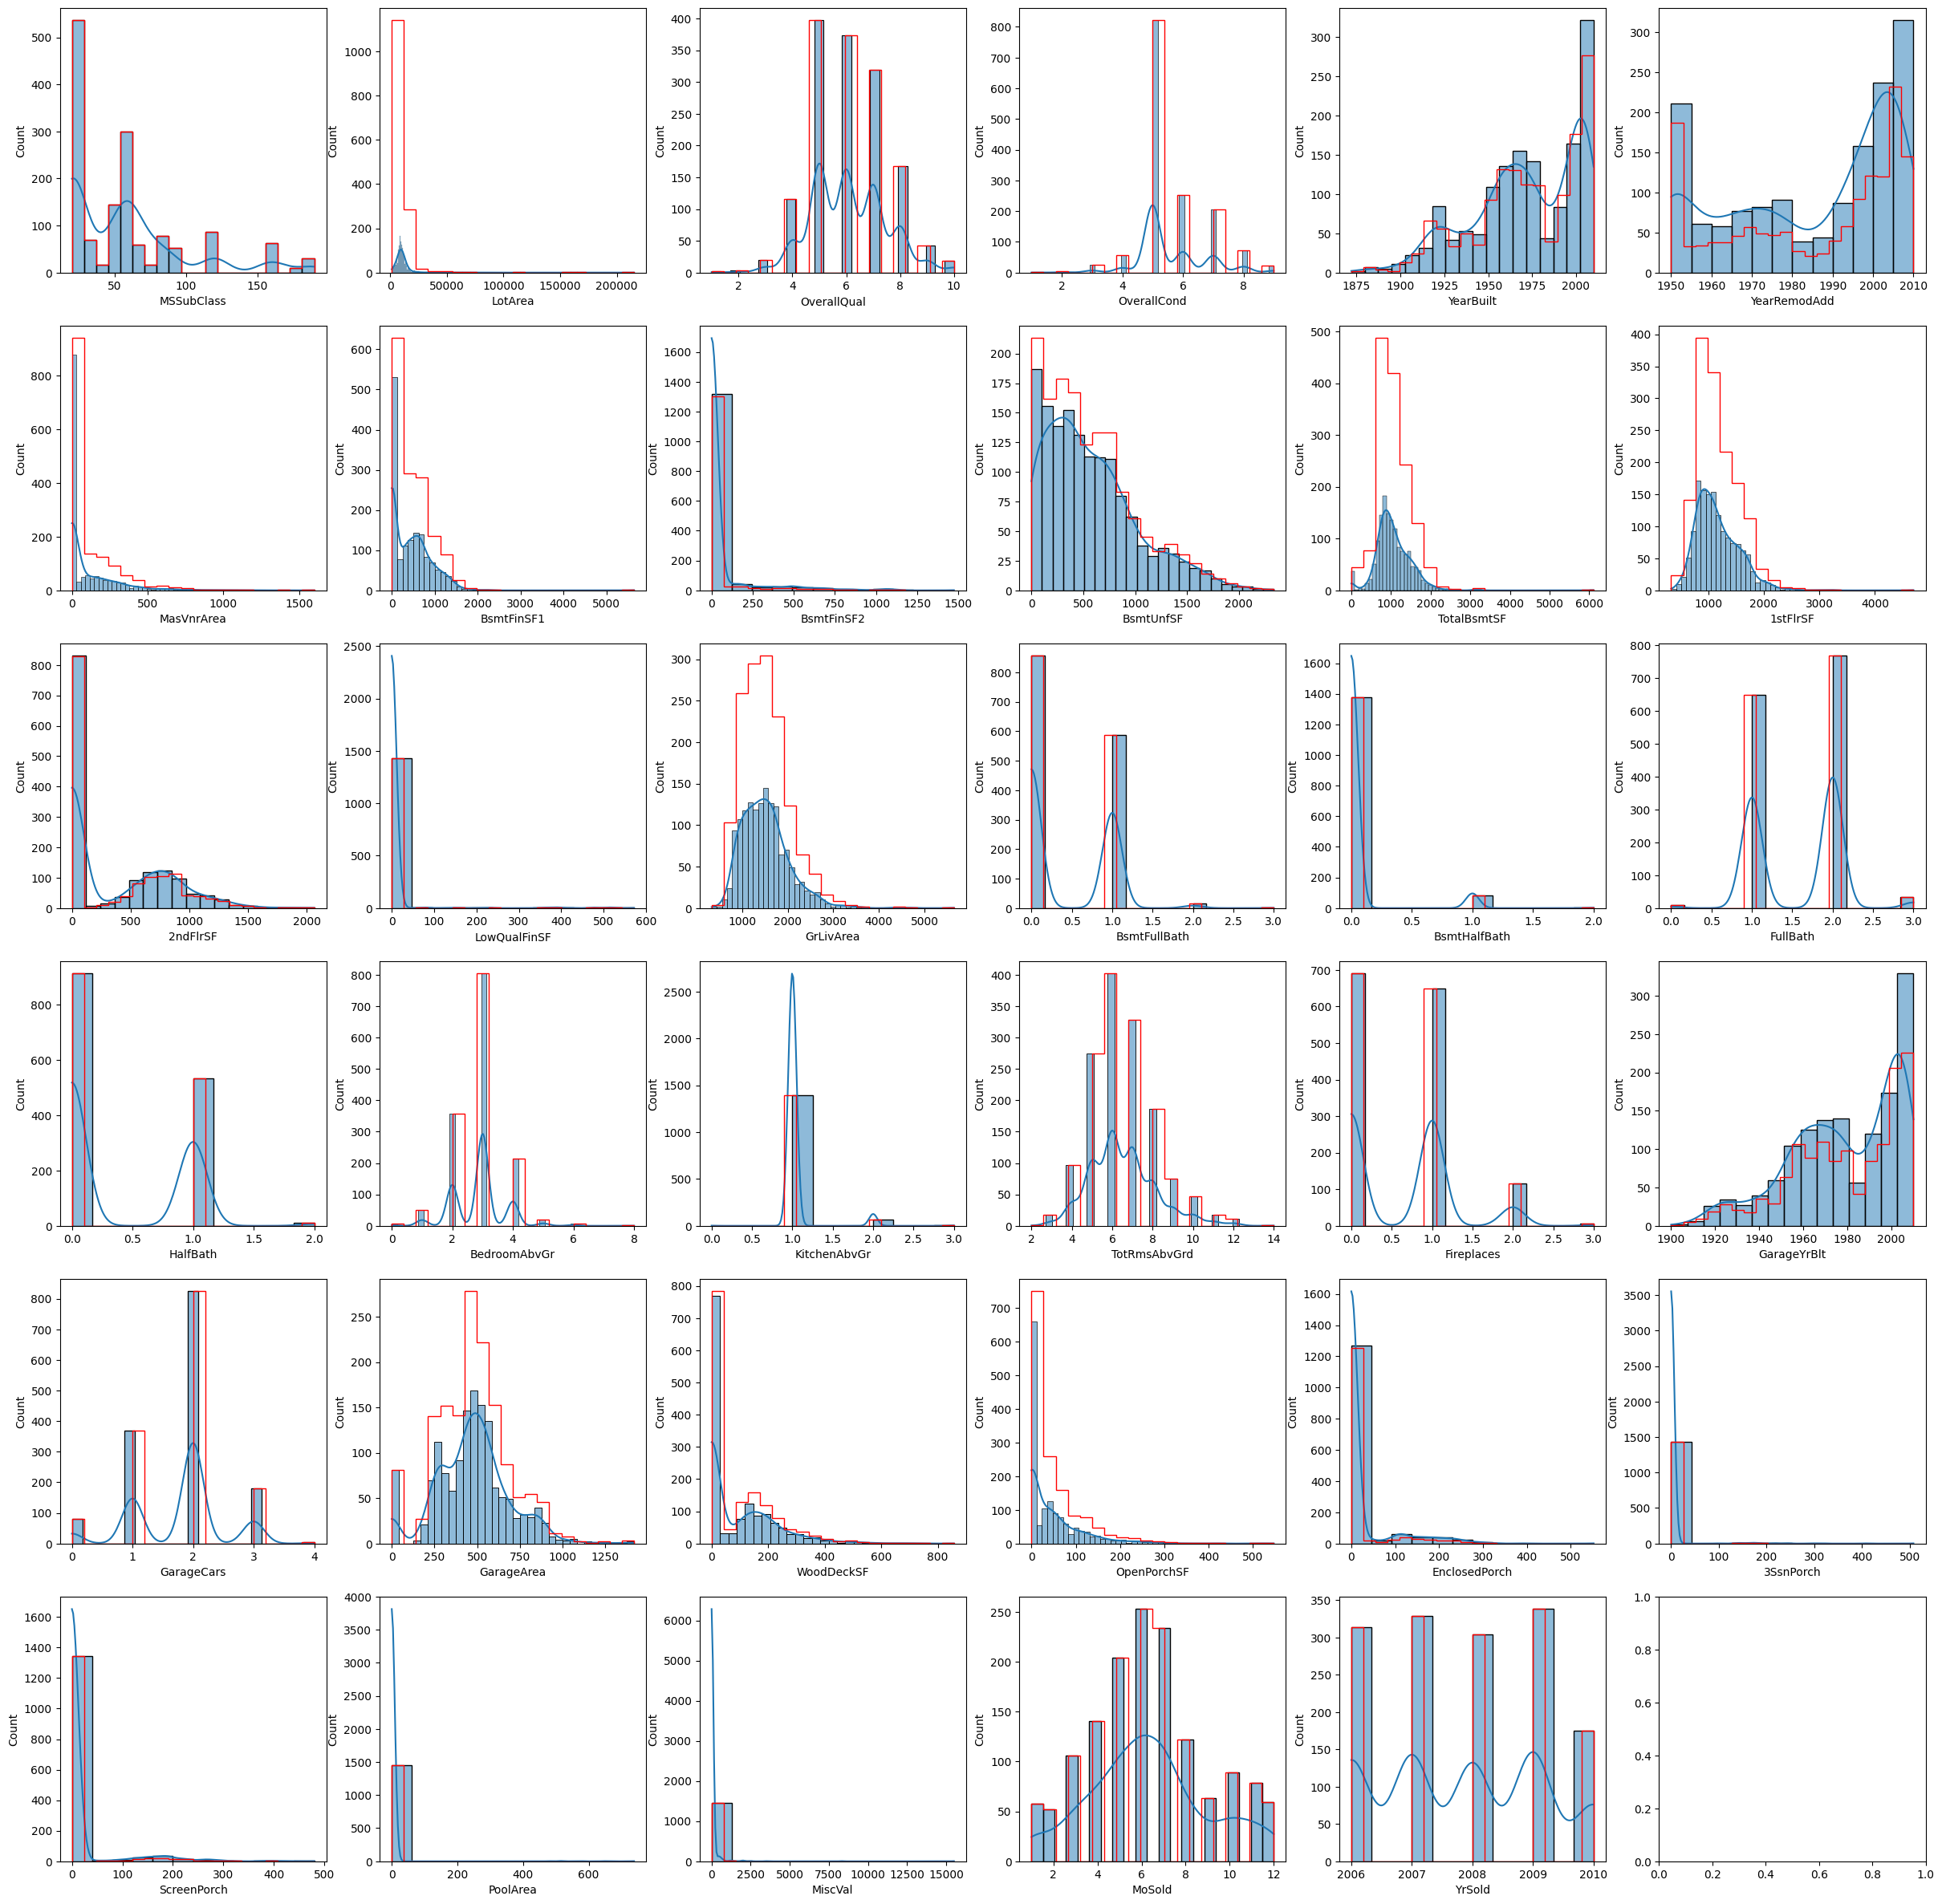

In [17]:
f,ax = plt.subplots(6,6, figsize=(30,30))
k=0
for i in range(6):
    for j in range(6):
        if k<35:
            sns.histplot(x=cont_features[k], data=data_temp, kde=True, ax=ax[i][j])
            ax[i][j].hist(data_temp[cont_features[k]], bins=20, histtype='step', color='Red')
            k=k+1
plt.show()


In [18]:
data_temp.drop(['MiscVal', 'PoolArea', 'ScreenPorch', '3SsnPorch', 'EnclosedPorch', 'KitchenAbvGr', 'BsmtHalfBath',
                'LowQualFinSF', 'BsmtFinSF2', 'MasVnrArea'], axis=1, inplace=True)

In [19]:
test_data.drop(['MiscVal', 'PoolArea', 'ScreenPorch', '3SsnPorch', 'EnclosedPorch', 'KitchenAbvGr', 'BsmtHalfBath',
                'LowQualFinSF', 'BsmtFinSF2', 'MasVnrArea'], axis=1, inplace=True)

### Seperating Dependent and Independent Feature

In [20]:
X = data_temp.iloc[:, :-1]
y = data_temp['SalePrice']

### Encoding Categorial Data

In [21]:
cat_features = np.array([i for i in data_temp.columns.tolist() if data_temp[i].dtype == 'object'])
cont_features = np.array([i for i in data_temp.columns.tolist() if data_temp[i].dtype != 'object'])

In [22]:
# Encoding train data
from sklearn.preprocessing import LabelEncoder
for i in cat_features:
    enc = LabelEncoder()
    X[i] =enc.fit_transform(X[i])

In [23]:
# Encoding test data
from sklearn.preprocessing import LabelEncoder
for i in cat_features:
    enc = LabelEncoder()
    test_data[i] =enc.fit_transform(test_data[i])

#### Co-relation Matrix 

<AxesSubplot: >

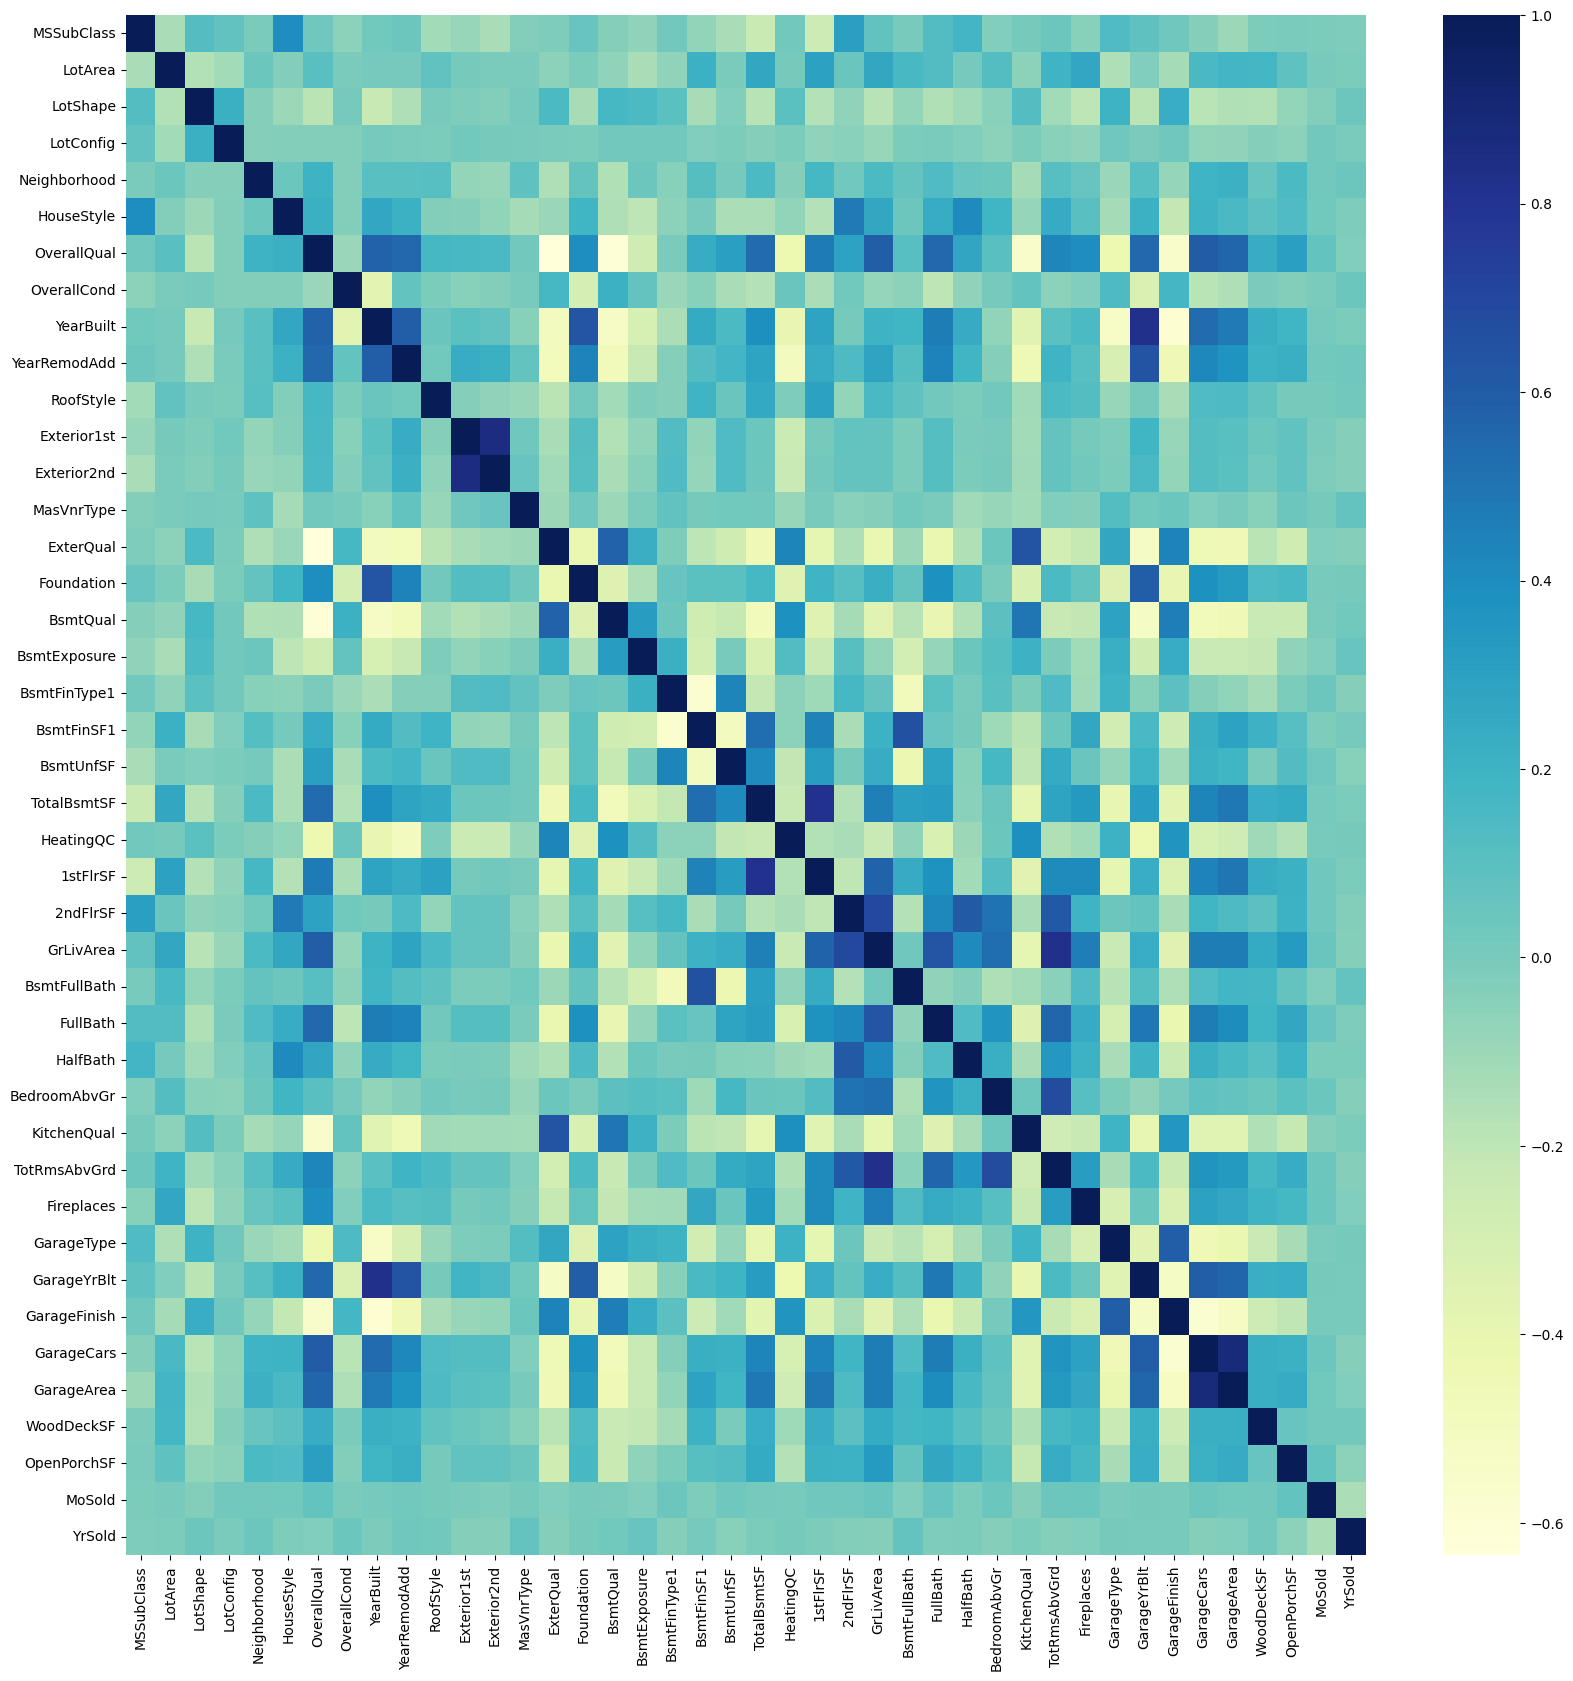

In [24]:
plt.figure(figsize=(20,20))
sns.heatmap(X.corr(), cmap='YlGnBu')

### Handle Nan Values

In [25]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=10)
X = imputer.fit_transform(X)

In [26]:
# test data
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=10)
test_data = imputer.fit_transform(test_data)

#### Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X,y, test_size=0.2, random_state=1)

## Deep Learning Model

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### ANN { Artificial Neural Network

In [29]:
import tensorflow as tf

# Create neural network
ann = tf.keras.models.Sequential()

# create input layer
ann.add(tf.keras.layers.Dense(units=50, activation='relu'))
ann.add(tf.keras.layers.Dense(units=50, activation='relu'))
ann.add(tf.keras.layers.Dense(units=50, activation='relu'))
ann.add(tf.keras.layers.Dense(units=50, activation='relu'))
ann.add(tf.keras.layers.Dense(units=50, activation='relu'))

# create output layer
ann.add(tf.keras.layers.Dense(units=1))

# Compile the network with stochastic gradient descent
ann.compile(optimizer= 'adam', loss= 'mean_squared_error')

# Train the network
ann.fit(X, y, batch_size=32, epochs=250)

Epoch 1/250
46/46 [==============================] - 2s 2ms/step - loss: 33913587712.0000
Epoch 2/250
46/46 [==============================] - 0s 2ms/step - loss: 15017107456.0000
Epoch 3/250
46/46 [==============================] - 0s 2ms/step - loss: 7743239680.0000
Epoch 4/250
46/46 [==============================] - 0s 2ms/step - loss: 6122807808.0000
Epoch 5/250
46/46 [==============================] - 0s 2ms/step - loss: 5185636864.0000
Epoch 6/250
46/46 [==============================] - 0s 2ms/step - loss: 4505698816.0000
Epoch 7/250
46/46 [==============================] - 0s 2ms/step - loss: 4021517824.0000
Epoch 8/250
46/46 [==============================] - 0s 2ms/step - loss: 3544190464.0000
Epoch 9/250
46/46 [==============================] - 0s 2ms/step - loss: 3150741760.0000
Epoch 10/250
46/46 [==============================] - 0s 2ms/step - loss: 2838380544.0000
Epoch 11/250
46/46 [==============================] - 0s 2ms/step - loss: 2550121984.0000
Epoch 12/250
46/4

In [30]:
ypred = ann.predict(test_data)
ypred = ypred.reshape(len(ypred),)

46/46 [==============================] - 0s 1ms/step


### Submission

In [31]:
subm = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

In [32]:
subm.SalePrice = ypred

In [33]:
subm

,Id,SalePrice
0,1461,130809.148438
1,1462,171729.171875
2,1463,204273.328125
3,1464,198201.859375
4,1465,179726.796875
...,...,...
1454,2915,84291.468750
1455,2916,95554.937500
1456,2917,188274.109375
1457,2918,111334.414062


In [34]:
subm.to_csv('submission.csv', index=False)

**You can check other models on regression for same data with data visializations and EDA at:**

[House Price Data Analysis and Prediction Model](https://www.kaggle.com/code/ashx010/house-price-data-analysis-and-prediction-model)